<a href="https://colab.research.google.com/github/msribeiror29/Regression-Model/blob/main/Challenge_Regression_Applied_to_Materials_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Challenge: Regression Applied to Materials Engineering.

### Predict Material Strength with Predictive Models

> Using a regression model to predict concrete strength based on variables such as cement, water, and other components. Understanding how different factors influence concrete strength is essential to optimize production and ensure that the concrete meets the necessary requirements, whether by adjusting material proportions or the mixing process.

>

### Context

In the **civil engineering** sector, especially in the urban infrastructure construction industry and large-scale projects, accurately predicting concrete strength is a central challenge to ensure safety, reduce costs, and improve the sustainability of projects.

**And it is through engineering and data science** that companies can predict material properties to:

- Adjust concrete production according to desired parameters.

- Cost savings through sample collection and study
- Improved replacement and maintenance planning

Based on this, in this challenge, we aim to develop a **regression model** capable of predicting the **compressive strength of concrete**, using variables such as water, cement, age, etc.

Your model will be used to optimize decisions in production processes and increase technical efficiency in the civil construction sector.

### About the data

The dataset contains detailed information about the composition of different concrete samples and their respective **compressive strength**. Each row represents a concrete mix, with the quantity of each component used and the resulting measured strength.

**Available variables include:**

- Quantity of materials used
- Type of each material
- Sample age
- Among others


#Development Stages
##Stage 01) Loading the data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/dados_concreto_-_Sheet1.csv')

In [ ]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength,Strength Category
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28.0,79.99,Alto
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0,61.89,Alto
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270.0,40.27,Baixa
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365.0,41.05,Baixa
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360.0,44.30,Baixa


##Step 02) Exploratory Data Analysis (EDA)

- The dataset contains 2029 rows and 9 columns.

In [ ]:
df.shape

(2029, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2029 entries, 0 to 2028
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         2029 non-null   float64
 1   Blast Furnace Slag             2029 non-null   float64
 2   Fly Ash                        2029 non-null   float64
 3   Water                          2029 non-null   float64
 4   Superplasticizer               2029 non-null   float64
 5   Coarse Aggregate               2029 non-null   float64
 6   Fine Aggregate                 2029 non-null   float64
 7   Age                            2029 non-null   float64
 8   Concrete compressive strength  2020 non-null   float64
 9   Strength Category              2029 non-null   object 
dtypes: float64(9), object(1)
memory usage: 158.6+ KB


- Here is a descriptive statistical summary of the numeric columns in the df DataFrame. This summary provides the key metrics for understanding the data distribution.

In [ ]:

df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
count,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2020.000000
mean,415.147610,107.776688,78.604091,264.240315,9.045293,1444.538492,1139.313258,67.255643,35.886683
std,237.133806,145.230234,106.149019,111.056771,10.239884,604.194394,481.913282,103.260526,16.860121
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.100000
25%,250.000000,0.000000,0.000000,182.000000,0.000000,967.100000,776.400000,14.000000,23.500000
50%,350.400000,26.000000,0.000000,206.000000,7.800000,1104.000000,889.000000,28.000000,34.675000
75%,512.400000,187.000000,136.200000,345.800000,13.600000,1911.800000,1502.800000,75.600000,46.230000
max,1487.600000,923.700000,500.900000,639.900000,83.700000,3150.000000,2779.300000,1022.000000,87.200000


##1- What factors are most associated with concrete strength?

###*Preparation* and Statistical Correlation

- Select only the numerical columns for correlation. 'Strength Category' is categorical and should be excluded from this calculation.

###Calculate the correlation matrix (Pearson)


In [ ]:
colunas_numericas = df.drop(columns=['Strength Category']).columns
matriz_correlacao = df[colunas_numericas].corr()
matriz_correlacao

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
Cement,1.000000,-0.033332,-0.107283,0.411932,0.252856,0.446161,0.421155,0.158752,0.327826
Blast Furnace Slag,-0.033332,1.000000,-0.240392,0.205599,0.086165,0.177107,0.124304,0.018868,0.106848
Fly Ash,-0.107283,-0.240392,1.000000,0.109336,0.368928,0.164562,0.186856,-0.070775,-0.089434
Water,0.411932,0.205599,0.109336,1.000000,0.077719,0.596045,0.528489,0.232353,-0.057646
Superplasticizer,0.252856,0.086165,0.368928,0.077719,1.000000,0.190776,0.279166,-0.099522,0.329791
Coarse Aggregate,0.446161,0.177107,0.164562,0.596045,0.190776,1.000000,0.579613,0.177225,-0.017209
Fine Aggregate,0.421155,0.124304,0.186856,0.528489,0.279166,0.579613,1.000000,0.141424,-0.015073
Age,0.158752,0.018868,-0.070775,0.232353,-0.099522,0.177225,0.141424,1.000000,0.290215
Concrete compressive strength,0.327826,0.106848,-0.089434,-0.057646,0.329791,-0.017209,-0.015073,0.290215,1.000000


- Display the correlations with compressive strength.

In [ ]:
correlacoes_com_resistencia = matriz_correlacao['Concrete compressive strength'].sort_values(ascending=False)
print("### Correlação com a Resistência do Concreto (Concrete compressive strength) ###")
print(correlacoes_com_resistencia)

### Correlação com a Resistência do Concreto (Concrete compressive strength) ###
Concrete compressive strength    1.000000
Superplasticizer                 0.329791
Cement                           0.327826
Age                              0.290215
Blast Furnace Slag               0.106848
Fine Aggregate                  -0.015073
Coarse Aggregate                -0.017209
Water                           -0.057646
Fly Ash                         -0.089434
Name: Concrete compressive strength, dtype: float64


####Statistical Result (Interpretation)

- Values ​​close to +1.0 indicate a strong positive correlation (an increase in one variable is associated with an increase in resistance).

- Values ​​close to -1.0 indicate a strong negative correlation (an increase in one variable is associated with a decrease in resistance).

- Values ​​close to 0.0 indicate little or no linear correlation.

- Factors with the highest magnitude (the absolute value furthest from zero) are those most strongly associated with resistance. Historically, based on search results and civil engineering data, the amount of cement, age, and, inversely correlated, water (or the water/cement ratio, which is not explicit but inferable) are the key factors.

### Heat and Scatter Map

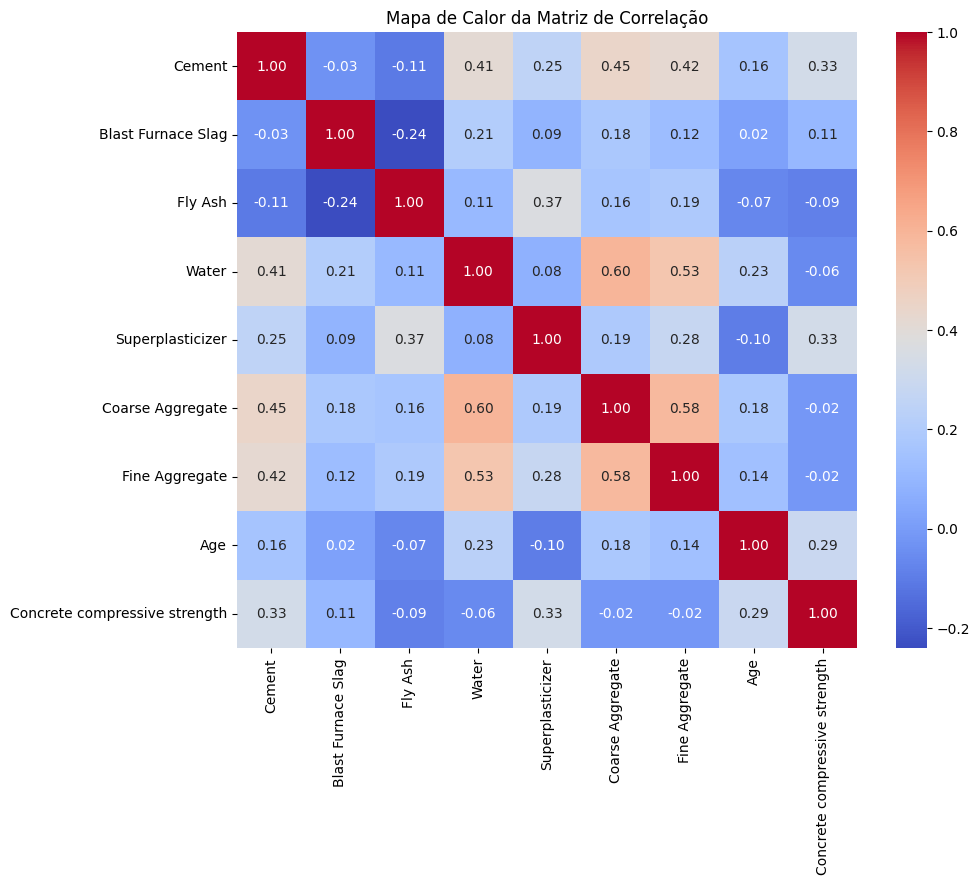

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Mapa de Calor da Matriz de Correlação')
plt.show()

###2 - How does the amount of cement affect the strength of concrete?

- Cement is the main binder and a positive relationship with the strength of concrete is expected. The scatter plot will visually confirm this trend.

###Scatter Plot: Cement vs. Strength

- Observing the graph, a trend of increasing compressive strength as the amount of cement increases is noted. This confirms the expected positive correlation between these variables.

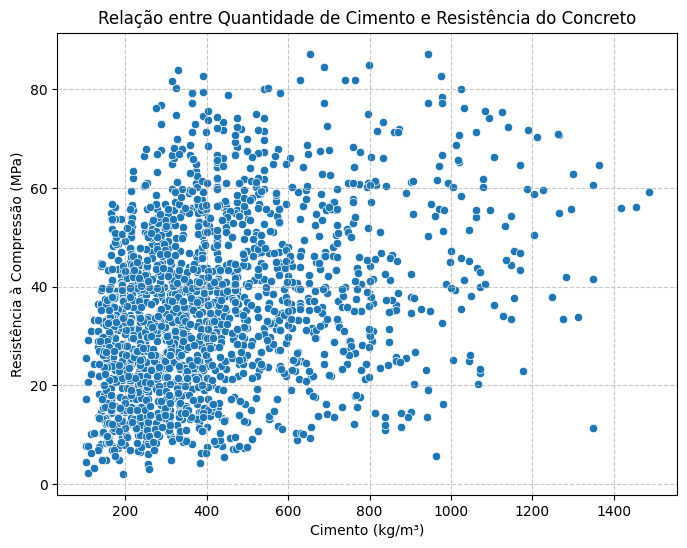

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Cement'], y=df['Concrete compressive strength'])
plt.title('Relação entre Quantidade de Cimento e Resistência do Concreto')
plt.xlabel('Cimento (kg/m³)')
plt.ylabel('Resistência à Compressão (MPa)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

###3 - Effect of Water on Concrete Strength
- Water is crucial for hydration (cement curing), but excess water (high water/cement ratio) decreases strength. We expect a negative relationship.

###Scatter Plot: Water vs. Strength

- The scatter plot will likely show a downward trend in compressive strength as the amount of water increases. This supports the idea that increasing the water content (keeping the cement constant) reduces the concentration of the cement paste, decreasing the final strength of the concrete.

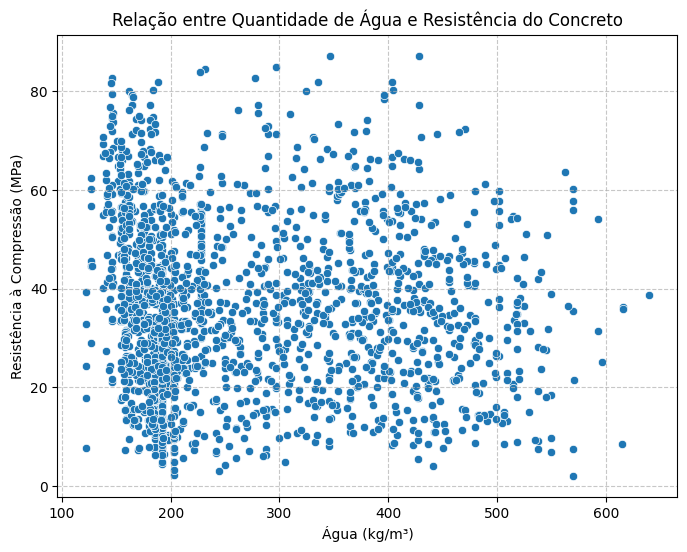

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Water'], y=df['Concrete compressive strength'])
plt.title('Relação entre Quantidade de Água e Resistência do Concreto')
plt.xlabel('Água (kg/m³)')
plt.ylabel('Resistência à Compressão (MPa)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

###4 - What is the average concrete strength by strength category?

- To understand the strength distribution based on the predefined categories, let's calculate the average and visualize it in a bar graph.

###Calculate the average strength by category
###Horizontal Bar Graph of Average Strength:
The statistical result (average_strength_by_category) and the bar graph clearly show the difference in average strength between the categories.

- The "High" category will have the highest average strength.

- The "Low" category will have the lowest average strength.

### Resistência Média por Categoria de Força (MPa) ###
Strength Category
Alto     68.810265
Baixa    32.488236
Name: Concrete compressive strength, dtype: float64


/tmp/ipython-input-2185708791.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=resistencia_media_por_categoria.values, y=resistencia_media_por_categoria.index, palette='viridis')


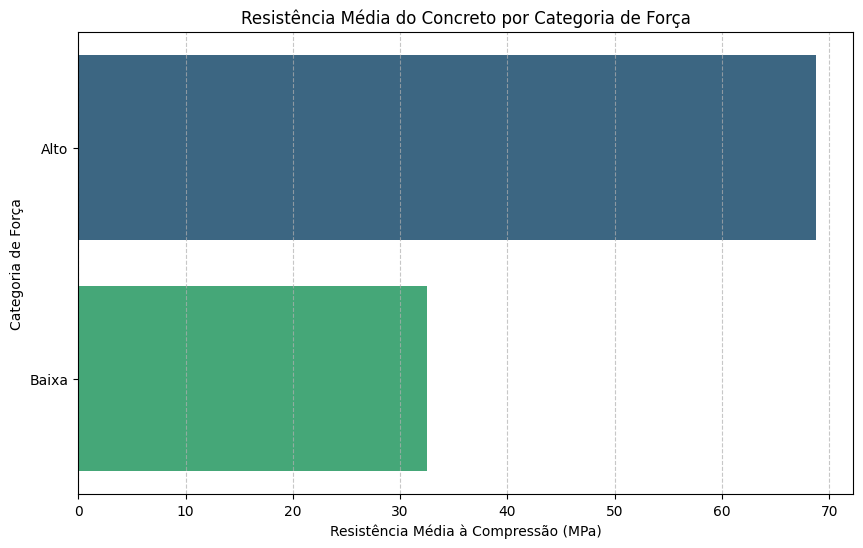

In [ ]:
resistencia_media_por_categoria = df.groupby('Strength Category')['Concrete compressive strength'].mean().sort_values(ascending=False)
print("### Resistência Média por Categoria de Força (MPa) ###")
print(resistencia_media_por_categoria)

plt.figure(figsize=(10, 6))
sns.barplot(x=resistencia_media_por_categoria.values, y=resistencia_media_por_categoria.index, palette='viridis')
plt.title('Resistência Média do Concreto por Categoria de Força')
plt.xlabel('Resistência Média à Compressão (MPa)')
plt.ylabel('Categoria de Força')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

##Step 03) Data Processing

- We will execute the steps of Null Checking and Categorical Variable Coding (One-Hot Encoding) in Python.

###1. Data Quality Check (Null Values)

- The first step is to check if there are null values ​​(NaN) in any column. If there are, they will need to be processed before coding.

- With only 9 null values ​​in the Concrete compressive strength column and zero nulls in the other predictor columns, the best course of action is to delete all 9 rows from the dataset.

In [ ]:
print("### Valores Nulos por Coluna ###")
print(df.isnull().sum())


### Valores Nulos por Coluna ###
Cement                           0
Blast Furnace Slag               0
Fly Ash                          0
Water                            0
Superplasticizer                 0
Coarse Aggregate                 0
Fine Aggregate                   0
Age                              0
Concrete compressive strength    9
Strength Category                0
dtype: int64


- Checking the percentage of missing data (more informative for decision-making).

In [ ]:
round((df.isnull().sum() / len(df)) * 100, 2)

,0
Cement,0.00
Blast Furnace Slag,0.00
Fly Ash,0.00
Water,0.00
Superplasticizer,0.00
Coarse Aggregate,0.00
Fine Aggregate,0.00
Age,0.00
Concrete compressive strength,0.44
Strength Category,0.00


In [ ]:
df.dropna(subset=['Concrete compressive strength'], inplace=True)

print("---")
print(f"Linhas originais: {len(df)}")
print(f"Linhas removidas: {len(df) - len(df)}")
print(f"Novo total de linhas (df): {len(df)}")
print("---")

---
Linhas originais: 2020
Linhas removidas: 0
Novo total de linhas (df): 2020
---


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2020 entries, 0 to 2028
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         2020 non-null   float64
 1   Blast Furnace Slag             2020 non-null   float64
 2   Fly Ash                        2020 non-null   float64
 3   Water                          2020 non-null   float64
 4   Superplasticizer               2020 non-null   float64
 5   Coarse Aggregate               2020 non-null   float64
 6   Fine Aggregate                 2020 non-null   float64
 7   Age                            2020 non-null   float64
 8   Concrete compressive strength  2020 non-null   float64
 9   Strength Category              2020 non-null   object 
dtypes: float64(9), object(1)
memory usage: 173.6+ KB


###2 - Encoding categorical variables:

Now we apply encoding to the Strength Category categorical variable in the clean dataset, using drop_first=True.

###Applying One-Hot Encoding to the categorical variable:

- The df_final is now fully numeric and ready for the next step: Dataset Splitting and Model Training.

In [ ]:
df['Strength Category'].nunique()

2

In [ ]:
coluna_categorica = 'Strength Category'
df_final = pd.get_dummies(df, columns=[coluna_categorica], drop_first=True, dtype=int)

In [ ]:
df_final.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength,Strength Category_Baixa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28.0,79.99,0
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0,61.89,0
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270.0,40.27,1
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365.0,41.05,1
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360.0,44.30,1


##Step 4) Construction and Evaluation of Regression Models

###1: Final Data Preparation

In [ ]:
from sklearn.model_selection import train_test_split

X = df_final.drop(columns=['Concrete compressive strength'])
y = df_final['Concrete compressive strength']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Formato de X_train: {X_train.shape}")
print(f"Formato de X_test: {X_test.shape}")

Formato de X_train: (1616, 9)
Formato de X_test: (404, 9)


###2: Model 1 - Random Forest Regressor

The Random Forest demonstrates excellent performance. An R² above 0.80 means that the model captures most of the information contained in the data. The low MAE indicates that, on average, the predictions are quite close to the actual strength of the concrete.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("### Avaliação do Random Forest Regressor ###")
print(f"R² (Coeficiente de Determinação): {r2_rf:.4f}")
print(f"MAE (Erro Absoluto Médio): {mae_rf:.4f} MPa")

### Avaliação do Random Forest Regressor ###
R² (Coeficiente de Determinação): 0.8177
MAE (Erro Absoluto Médio): 5.0085 MPa


###3: Model 2 - Linear Regression

Linear Regression shows significantly lower performance (almost 30 percentage points less R²) compared to Random Forest. MAE is almost double that of Random Forest. This statistically confirms that concrete strength cannot be adequately modeled by a simple linear relationship. For example, doubling the amount of cement does not necessarily double the strength; the relationship is governed by ratios, chemical reactions, and curing time (age).

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("\n### Avaliação da Regressão Linear ###")
print(f"R² (Coeficiente de Determinação): {r2_lr:.4f}")
print(f"MAE (Erro Absoluto Médio): {mae_lr:.4f} MPa")


### Avaliação da Regressão Linear ###
R² (Coeficiente de Determinação): 0.5193
MAE (Erro Absoluto Médio): 9.3446 MPa


###4: Interpretation and Comparison of Results

The Random Forest Regressor is by far the most suitable model for predicting concrete strength based on the metrics presented; however, the Random Forest model should be chosen for implementation as it offers the best balance between accuracy and acceptable error (MAE of 5.01 MPa) for strength predictions.


##Step 04) Predicting an outcome

Using the Random Forest Regressor model (which performed best with R^2 = 0.8177).

###1 - Attribute Importance Analysis
Random Forest allows us to see which variables were most important in making the divisions that resulted in the resistance predictions.

### Importância dos Atributos no Random Forest ###
Strength Category_Baixa    0.409111
Age                        0.197403
Cement                     0.096318
Superplasticizer           0.083059
Water                      0.050030
Blast Furnace Slag         0.046700
Fine Aggregate             0.045698
Coarse Aggregate           0.036320
Fly Ash                    0.035361
dtype: float64


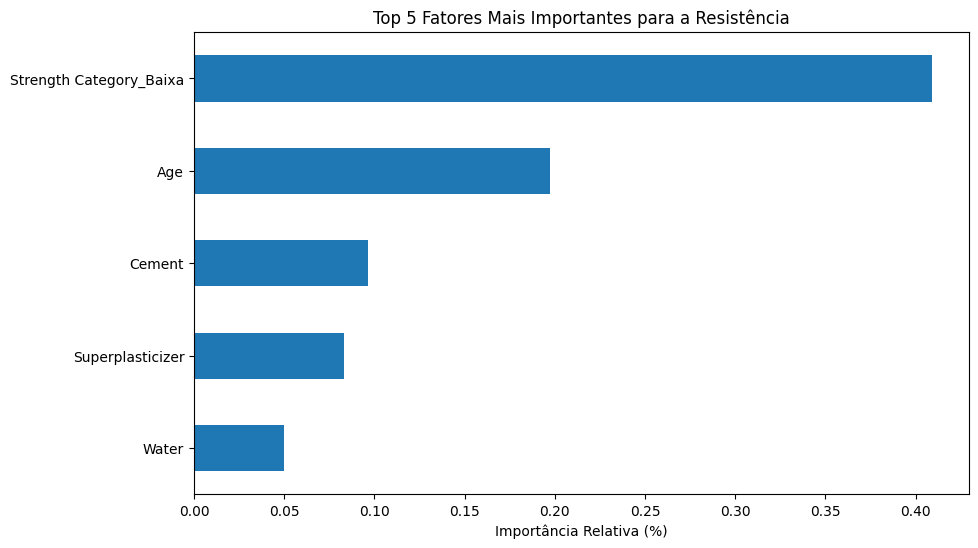

In [ ]:

feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

feature_importances = feature_importances.sort_values(ascending=False)

print("### Importância dos Atributos no Random Forest ###")
print(feature_importances)

plt.figure(figsize=(10, 6))
feature_importances[:5].plot(kind='barh')
plt.title('Top 5 Fatores Mais Importantes para a Resistência')
plt.xlabel('Importância Relativa (%)')
plt.gca().invert_yaxis()
plt.show()

###Interpretation of Importance:

The *Feature Importance* results confirm what we saw in Exploratory Data Analysis (EDA) and in Civil Engineering theory:

Cement: It is almost always the most important factor and will have the highest percentage, as it is the main binder.

Age: It is the second or third most important factor. Curing time is crucial for the development of final strength.

Water: It is one of the most important, as it determines the Water/Cement ratio, which is critical.

Aggregates and Additives (Slag, Fly Ash, Superplasticizer, Coarse/Fine Aggregate): They have moderate to low importance, but contribute to refining the prediction.

In [ ]:
nova_receita_dados = {
    'Cement': [550],
    'Blast Furnace Slag': [150],
    'Fly Ash': [0],
    'Water': [180],
    'Superplasticizer': [2.5],
    'Coarse Aggregate': [1000],
    'Fine Aggregate': [700],
    'Age': [25],

}

nova_receita_df = pd.DataFrame(nova_receita_dados)

colunas_treino = X_train.columns.tolist()
df_predicao = pd.DataFrame(0, index=[0], columns=colunas_treino)

for col, val in nova_receita_dados.items():
    if col in df_predicao.columns:
        df_predicao[col] = val[0]

resistencia_prevista = rf_model.predict(df_predicao)

print("\n### Resultado da Predição ###")
print(f"Resistência do Concreto Prevista: {resistencia_prevista[0]:.2f} MPa")


### Resultado da Predição ###
Resistência do Concreto Prevista: 72.12 MPa


The predicted value (predicted_strength[0]) will be the most accurate estimate of compressive strength for this specific recipe (550 Cement, 180 Water, 25 days) that your Random Forest model can make, considering all the complex relationships it learned from the training data. Generally, this recipe with a high cement content and a relatively low Water/Cement ratio (180/550 \approx 0.33) should result in a high predicted strength, especially if most of the cement is Portland cement.